In [1]:

import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, MiniBatchKMeans
from scipy.spatial.distance import cdist
import time
from scipy.spatial.distance import jensenshannon
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA
import pandas as pd
import sys
sys.path.insert(0, "/home/adamm/Desktop/filtered-vector-search/ACORN/build/faiss/python")
import faiss

from helper_funcs import *

In [2]:
vecs, queries, gts = import_dataset()

print(f"Dimensions of base: {vecs.shape}    Type: {vecs.dtype}")
print(f"Dimensions of query: {queries.shape}    Type: {queries.dtype}")
print(f"Dimensions of truth: {gts.shape}    Type: {gts.dtype}")

Dimensions of base: (10000, 128)    Type: float32
Dimensions of query: (100, 128)    Type: float32
Dimensions of truth: (100, 100)    Type: int32


Since we are creating artificial attributes, we don't need *TRUE* optimal clustering.

We aim to have enough clusers to create attribute variation. So we can use two heuristics to choose $k$

- $k = \sqrt N$
- $k = \frac{N} {100}$


In [3]:
k = np.int32(np.sqrt(vecs.shape[0]))

### Generating Positively Correlated Continuous Attributes

1. **Cluster the vectors** (e.g., using KMeans).
2. **Assign each cluster a base attribute value**.
3. **Compute a vector's attribute** as the cluster value plus a smooth decay depending on its distance from the centroid.

This produces the following behavior:

- **Inside a cluster** → very similar attribute values  
- **Near a cluster** → similar values  
- **Far from a cluster** → increasingly different values  

As a result, vectors that are close in embedding space receive similar attribute values, creating a **positive correlation with the vector space**.

### Smooth Attribute Assignment

Instead of only using the assigned cluster, use **all cluster centers with distance weighting**.  
This avoids sharp boundaries between clusters.

The attribute value for a vector $x$ is computed as:

$$
a(x) =
\frac{
\sum_i v_i e^{-\|x - c_i\|^2 / \sigma^2}
}{
\sum_i e^{-\|x - c_i\|^2 / \sigma^2}
}
$$

where

- $c_i$ = centroid of cluster $i$  
- $v_i$ = base attribute value assigned to cluster $i$  
- $\sigma$ = smoothing parameter controlling how quickly influence decays with distance

In [4]:
attr, labels = generate_correlated_attribute(vecs, k)

Average attribute diff with neighbors: 10.524803573098302


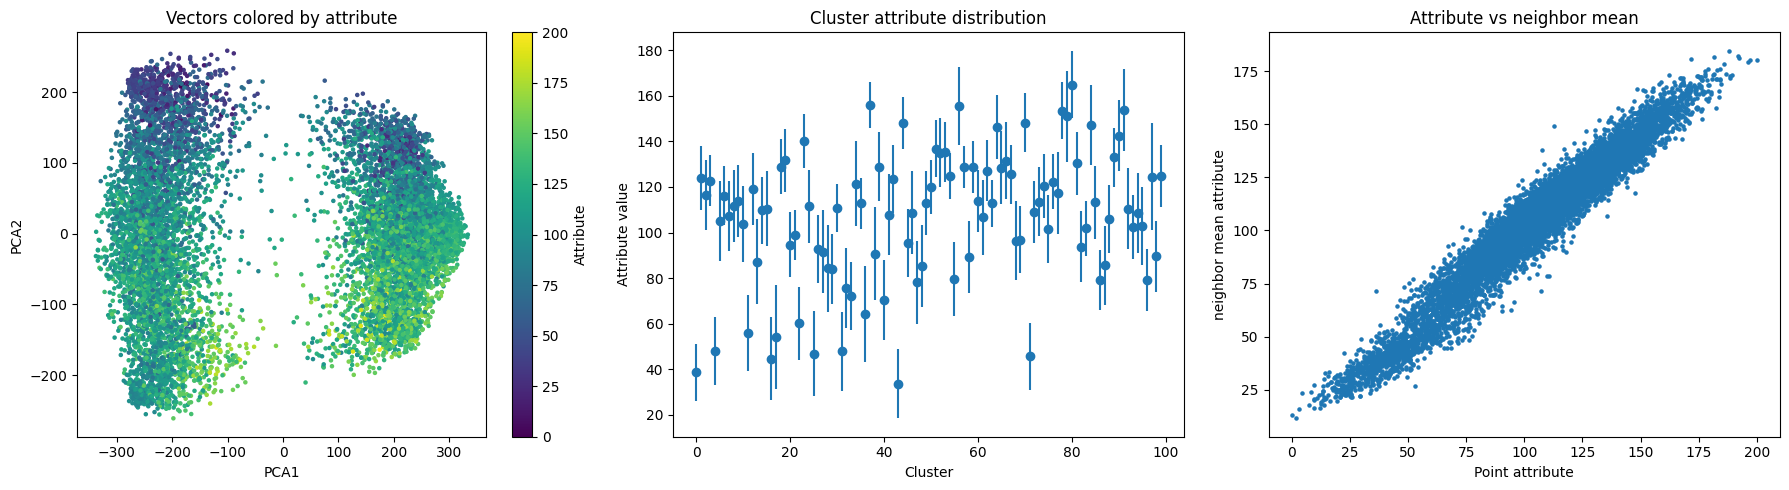

In [5]:
stats = compute_neighbor_stats(vecs, attr)
vecs_2d = PCA(n_components=2).fit_transform(vecs)

print(f"Average attribute diff with neighbors: {stats["neighbor_diff_mean"]}")
plot_attribute_analysis(vecs_2d, attr, stats["neighbor_mean"], labels)

### Generating Random Continuous Attributes
Each vector $x$ receives an attribute value sampled independently:

$$
a(x) \sim U(0, MAX 200)
$$

where $U(0, 200)$ denotes a **uniform distribution** between 0 and 200.

- **Inside a cluster** → attribute values are random  
- **Near a cluster** → no systematic similarity  
- **Far from a cluster** → no systematic difference  

As a result, the attribute column is **statistically independent of the embedding space**.


In [6]:
rand_attr, rand_labels = generate_random_attribute(vecs)

Average attribute diff with neighbors: 59.8943914307726


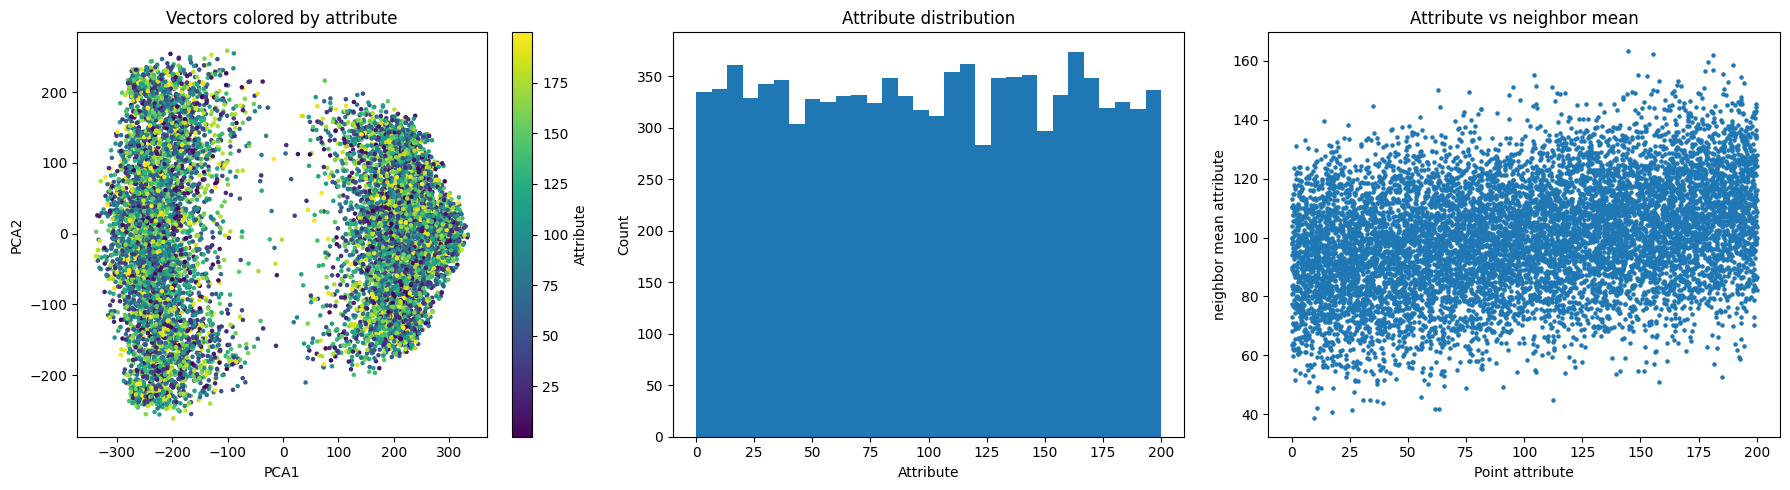

In [7]:
rand_stats = compute_neighbor_stats(vecs, rand_attr)
rand_vecs_2d = PCA(n_components=2).fit_transform(vecs)

print(f"Average attribute diff with neighbors: {rand_stats["neighbor_diff_mean"]}")
plot_attribute_analysis(rand_vecs_2d, rand_attr, rand_stats["neighbor_mean"], rand_labels)

### Query Construction Strategy

For each query $q$:

1. Find its $k$ nearest dataset vectors  
2. Look at their attribute values  
3. Build a range filter

**Positive query**

- Range overlaps with neighbor attributes.

**Negative query**

- Range avoids neighbor attributes.

**Random query**

- For the random correlation, we can just use the ranges of the postiive correlated queries on the randomly corrleated attribute

### Algorithm

For query $q$:

1. Compute nearest neighbors  
2. Extract neighbor attributes  
3. Compute:

$$
a_{\min}, a_{\max}
$$

Then:

**Positive query**

$$
[a_{\min}, a_{\max}]
$$

**Negative query**

Choose a range **outside this interval**.

$$
[0, a_{\min}]
$$
or 
$$
[a_{\max}, 200]
$$
#### **Example**

- Attribute domain: $[0, 200]$

- Neighbors: $[80, 110]$

- Positive range → $[75, 115]$  
- Negative range → $[0, 60]$ or $[130, 200]$

In [8]:
pos_ranges, neg_ranges = generate_query_ranges(vecs, attr, queries, k)

df_pos = pd.DataFrame({
    "query_id": range(len(queries)),
    "range": pos_ranges,
    "label": "positive"
})

df_neg = pd.DataFrame({
    "query_id": range(len(queries)),
    "range": neg_ranges,
    "label": "negative"
})

df = pd.concat([df_pos, df_neg], ignore_index=True)

print(df)

     query_id                                    range     label
0           0    (69.664940377221, 160.58161471461838)  positive
1           1   (74.43606177157447, 163.0946989027009)  positive
2           2   (5.777309549184833, 112.4273675182155)  positive
3           3   (89.90727549875056, 162.2701424919073)  positive
4           4  (66.45188675857439, 139.88334901487858)  positive
..        ...                                      ...       ...
195        95                (0.0, 39.590077741474865)  negative
196        96              (164.93862723337904, 200.0)  negative
197        97                 (0.0, 72.58749000529028)  negative
198        98               (90.56162180635415, 200.0)  negative
199        99                (0.0, 103.27044454489813)  negative

[200 rows x 3 columns]


---

In [9]:
fitted_vecs = KMeans(n_clusters=k).fit(vecs)

threshold = 1.1 # 10% larger radius
hists, cdfs = compute_cluster_stats(fitted_vecs, vecs, attr, threshold)

